In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv("../data/cleaned_online_retail.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
#Section 1: Transactions by Country Top 10 Countries by Number of Transactions
country_transactions = df['Country'].value_counts().head(10)

country_transactions

Country
United Kingdom    354345
Germany             9042
France              8342
EIRE                7238
Spain               2485
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1462
Australia           1185
Name: count, dtype: int64

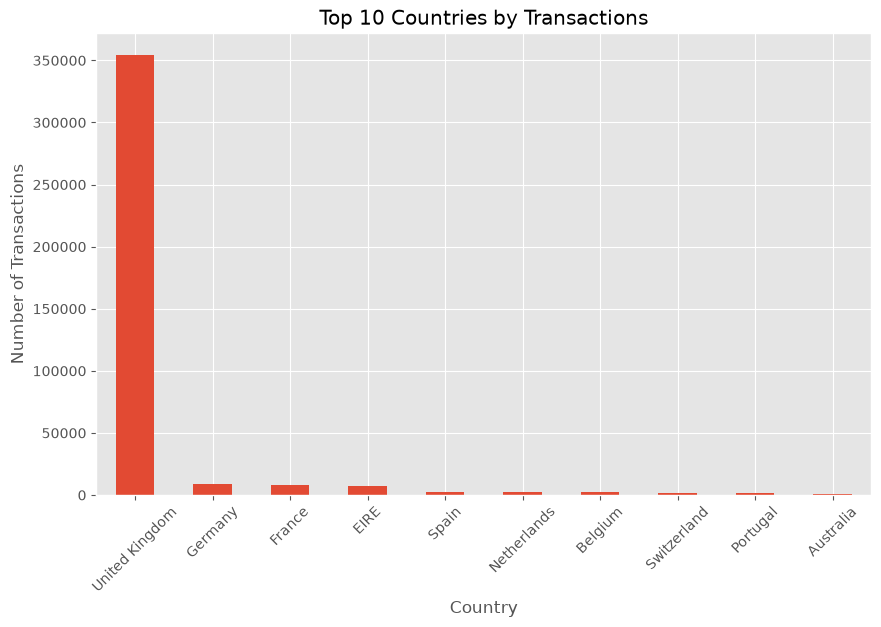

In [5]:
plt.figure(figsize=(10,6))

country_transactions.plot(kind='bar')

plt.title("Top 10 Countries by Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [6]:
# Top Selling Products
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

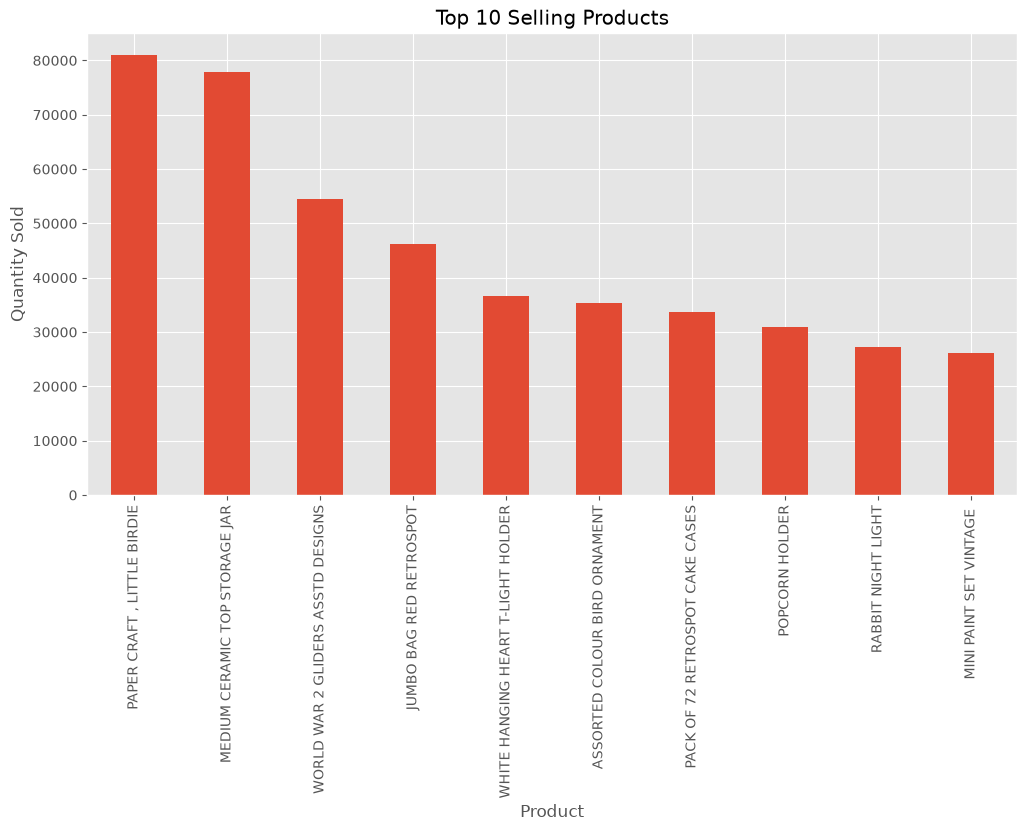

In [7]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.show()

In [9]:
#Purchase Trends Over Time

# Create a Months Column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

#Monthly revenue
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales

Month
2022-12     572713.890
2023-01     569445.040
2023-02     447137.350
2023-03     595500.760
2023-04     469200.361
2023-05     678594.560
2023-06     661213.690
2023-07     600091.011
2023-08     645343.900
2023-09     952838.382
2023-10    1039318.790
2023-11    1161817.380
2023-12     518192.790
Freq: M, Name: TotalPrice, dtype: float64

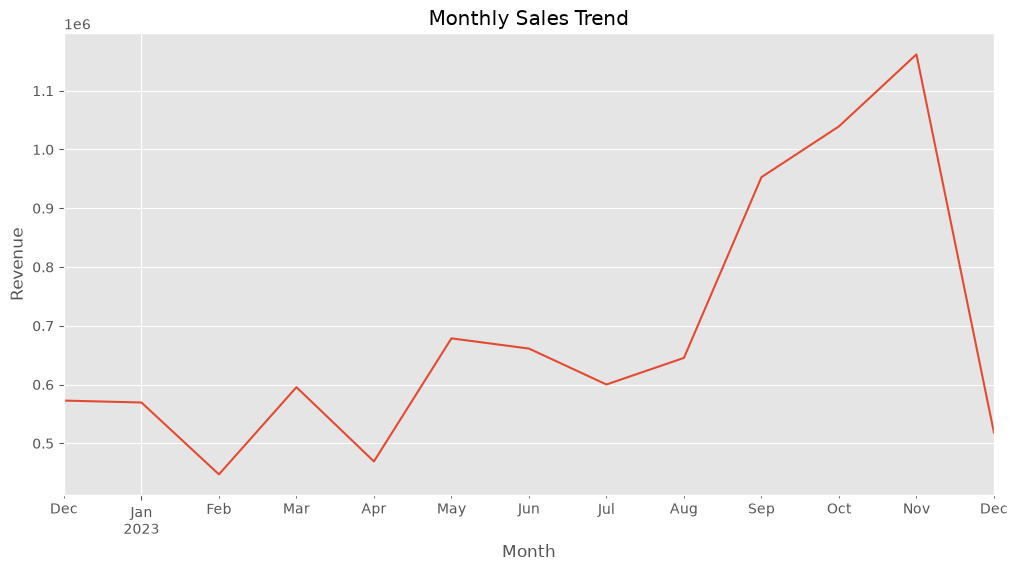

In [10]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

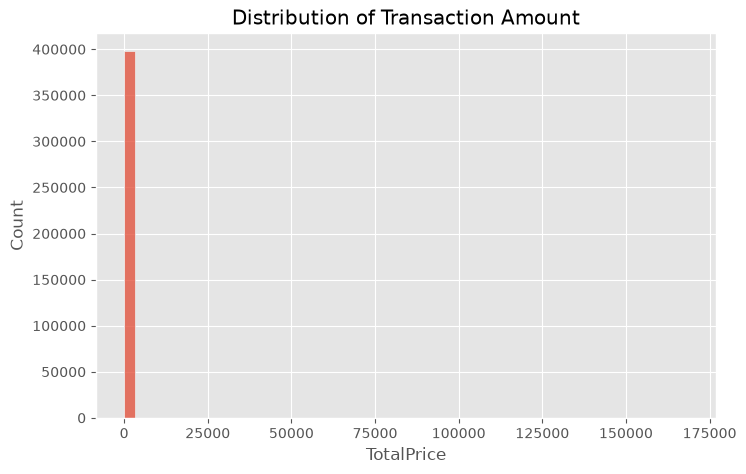

In [11]:
# Transaction Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['TotalPrice'], bins=50)

plt.title("Distribution of Transaction Amount")

plt.show()

In [14]:
# Top Revenue Countries
country_revenue = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

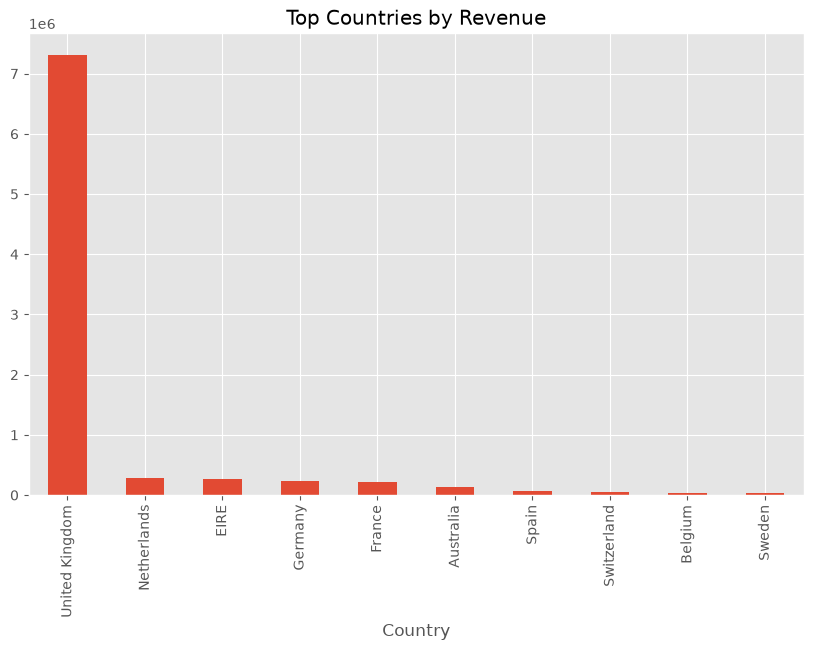

In [15]:
plt.figure(figsize=(10,6))

country_revenue.plot(kind='bar')

plt.title("Top Countries by Revenue")

plt.show()

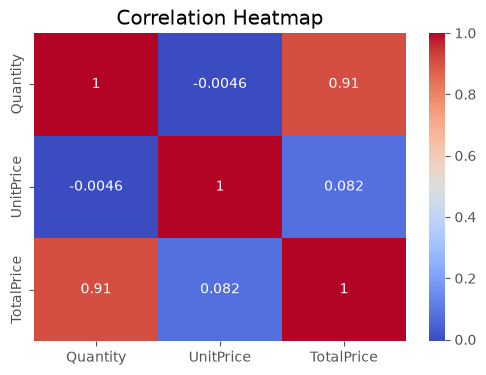

In [17]:
#Correlation Heatmap
numeric_df = df[['Quantity','UnitPrice','TotalPrice']]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

There is a strong positive correlation (0.91) between Quantity and TotalPrice, indicating that larger purchases significantly contribute to higher transaction values.

UnitPrice exhibits only a weak positive relationship with TotalPrice, suggesting that transaction value depends more on purchase quantity than on individual item prices.

Quantity and UnitPrice are essentially uncorrelated, implying that the number of products purchased does not strongly depend on product price.